In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

output_dir = "grafici_final"
os.makedirs(output_dir, exist_ok=True)

<h4> Ucitavanje izvora 

In [3]:
df_all       = pd.read_csv("rezultati_all.csv")
df_text      = pd.read_csv("rezultati_textonly.csv")
df_reduced   = pd.read_csv("rezultati_reduced.csv")

df_all['Set']     = 'Svi Atributi'
df_text['Set']    = 'Samo Tekst'
df_reduced['Set'] = 'Redukovani (SVD)'

# Spajanje u master DataFrame
df_master = pd.concat([df_all, df_text, df_reduced], ignore_index=True)

print("Ucitano ukupno redova:", len(df_master))
print("Setovi:", df_master['Set'].unique())
print("Kolone:", df_master.columns.tolist())

Ucitano ukupno redova: 27
Setovi: <StringArray>
['Svi Atributi', 'Samo Tekst', 'Redukovani (SVD)']
Length: 3, dtype: str
Kolone: ['Algoritam', 'n_clusters', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz', 'Set']


<h4>UKLANJANJE DBSCAN IZ POREDJENJA METRIKA
<h5>(DBSCAN ima misleading Silhouette - komentarisemo ga zasebno)

In [5]:
df_no_dbscan = df_master[~df_master['Algoritam'].str.contains('DBSCAN')].copy()
df_dbscan    = df_master[df_master['Algoritam'].str.contains('DBSCAN')].copy()

<h3>KOMPLETNA UPOREDNA TABELA

In [6]:
print("\n" + "="*90)
print("DETALJAN UPOREDNI PREGLED SVIH METRIKA KROZ SVE SETOVE PODATAKA")
print("="*90)

finalna_tabela = df_master.pivot_table(
    index=['Set', 'Algoritam'],
    values=['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']
)[['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']]

pd.set_option('display.max_rows', None)
pd.set_option('display.width', 120)
print(finalna_tabela.round(4))
print("="*90)


DETALJAN UPOREDNI PREGLED SVIH METRIKA KROZ SVE SETOVE PODATAKA
                                                Silhouette  Davies-Bouldin  Calinski-Harabasz
Set              Algoritam                                                                   
Redukovani (SVD) Agglomerative(k=5)                 0.0658          3.0436           237.4553
                 Agglomerative(k=8)                 0.0744          3.2202           184.0364
                 DBSCAN(eps=0.4,min_samples=3)      0.6769          0.6178            60.7722
                 KMeans(k=5)                        0.0907          2.9910           277.2727
                 KMeans(k=8)                        0.1056          4.3226           220.7277
                 MiniBatchKMeans(k=5)               0.0878          5.3740           257.0431
                 MiniBatchKMeans(k=8)               0.1004          4.3352           206.1139
                 Spectral(k=5)                      0.0345          2.4111           134.

<h3>GRAFIKON - SILHOUETTE (bez DBSCAN)

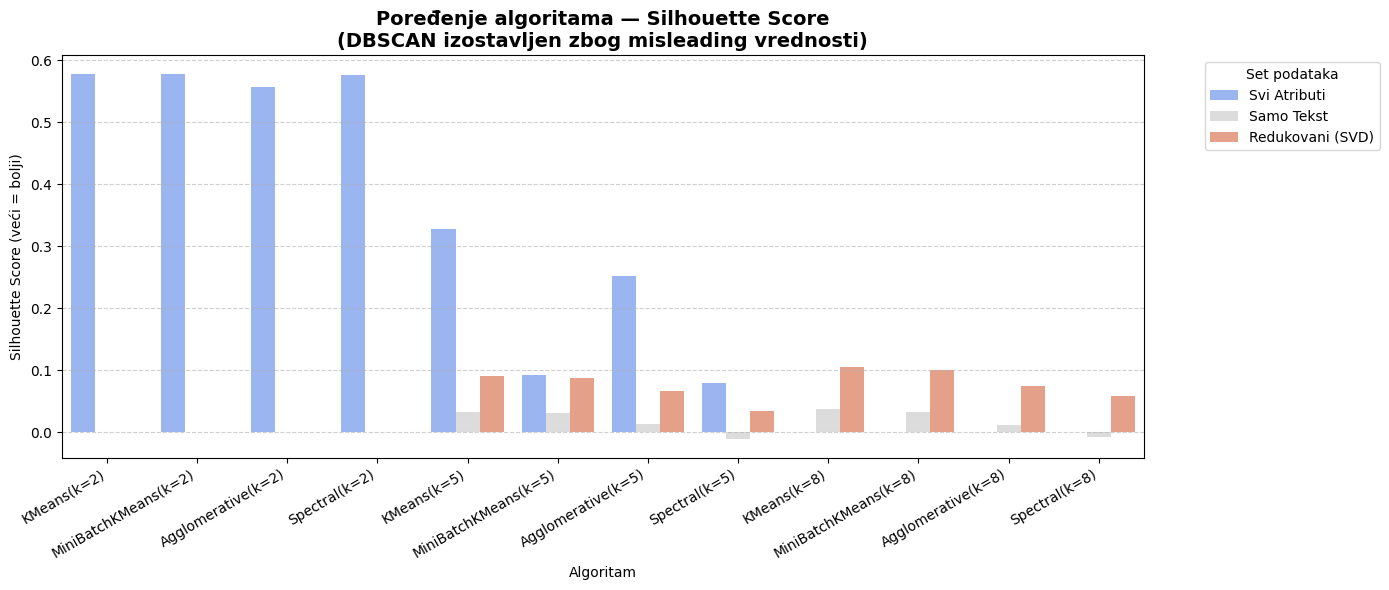

In [9]:
plt.figure(figsize=(14, 6))
sns.barplot(
    data=df_no_dbscan,
    x='Algoritam', y='Silhouette', hue='Set',
    palette='coolwarm'
)
plt.title('Poređenje algoritama — Silhouette Score\n(DBSCAN izostavljen zbog misleading vrednosti)',
          fontsize=14, fontweight='bold')
plt.ylabel('Silhouette Score (veći = bolji)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Set podataka', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "porednenje_silhouette.png"), dpi=150)
plt.show()

<h3>GRAFIKON - DAVIES-BOULDIN (bez DBSCAN)

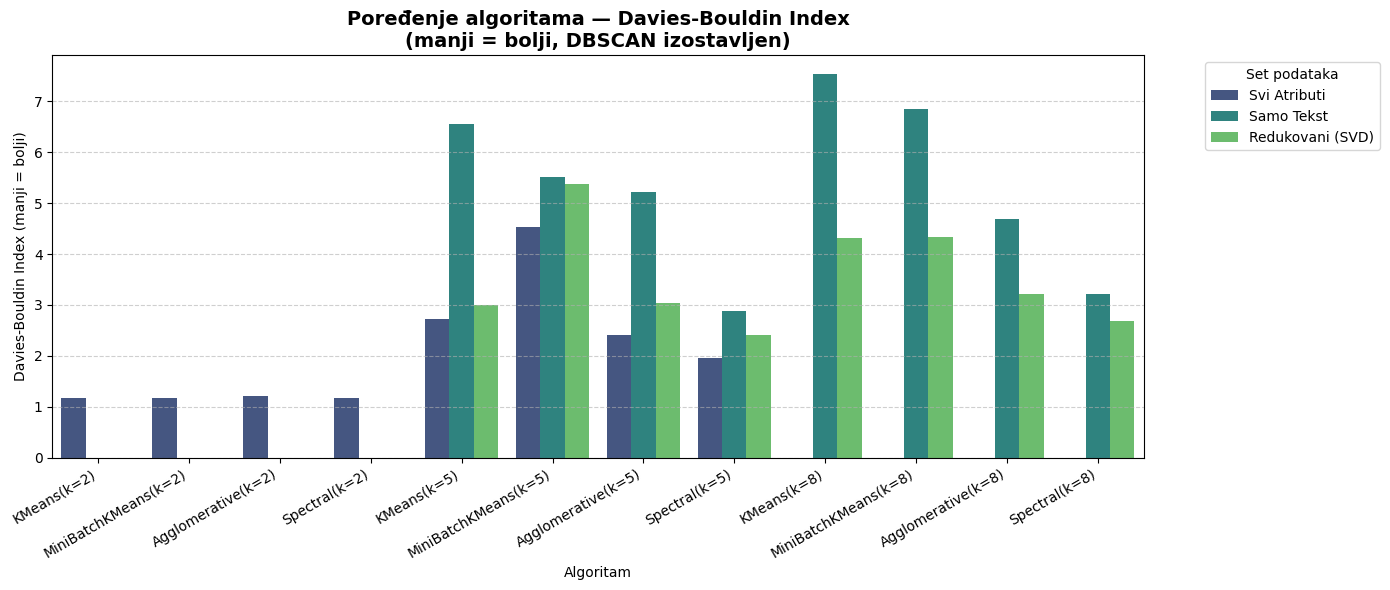

In [10]:
plt.figure(figsize=(14, 6))
sns.barplot(
    data=df_no_dbscan,
    x='Algoritam', y='Davies-Bouldin', hue='Set',
    palette='viridis'
)
plt.title('Poređenje algoritama — Davies-Bouldin Index\n(manji = bolji, DBSCAN izostavljen)',
          fontsize=14, fontweight='bold')
plt.ylabel('Davies-Bouldin Index (manji = bolji)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Set podataka', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "poređenje_davies_bouldin.png"), dpi=150)
plt.show()

<h3>GRAFIKON - CALINSKI-HARABASZ(bez DBSCAN)

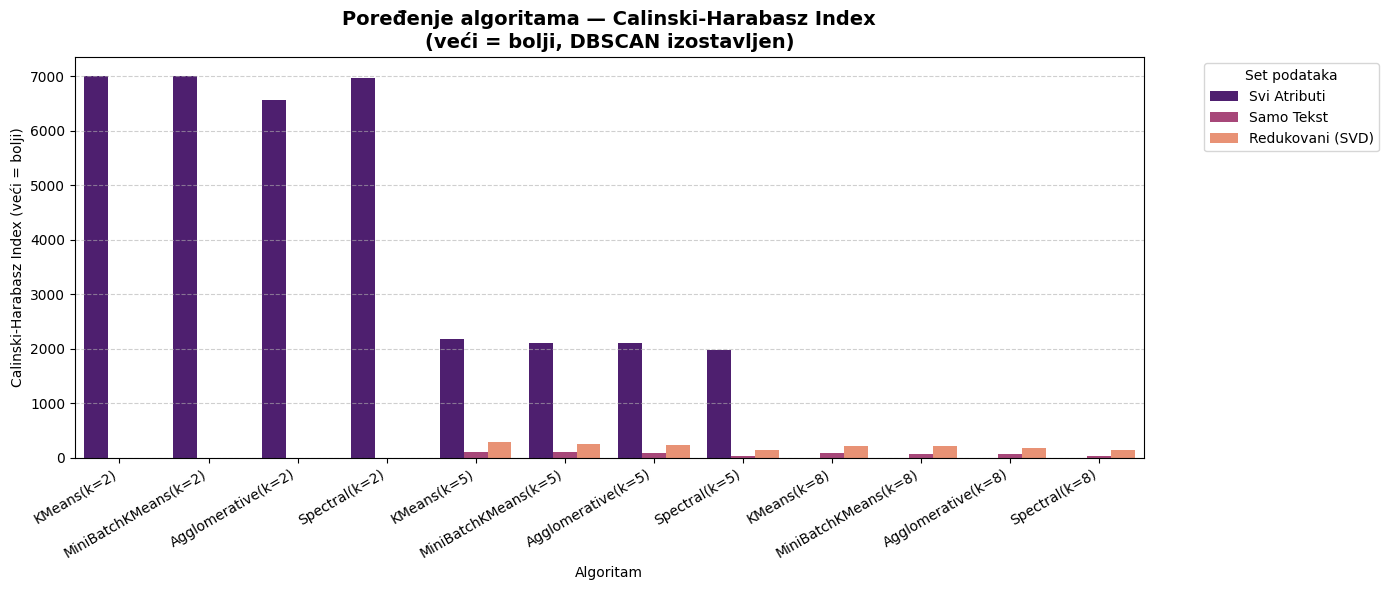

In [11]:
plt.figure(figsize=(14, 6))
sns.barplot(
    data=df_no_dbscan,
    x='Algoritam', y='Calinski-Harabasz', hue='Set',
    palette='magma'
)
plt.title('Poređenje algoritama — Calinski-Harabasz Index\n(veći = bolji, DBSCAN izostavljen)',
          fontsize=14, fontweight='bold')
plt.ylabel('Calinski-Harabasz Index (veći = bolji)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Set podataka', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "poredenje_calinski_harabasz.png"), dpi=150)
plt.show()

<h3>HEATMAPA - SVE METRIKE ZA SVAKI SET (bez DBSCAN)

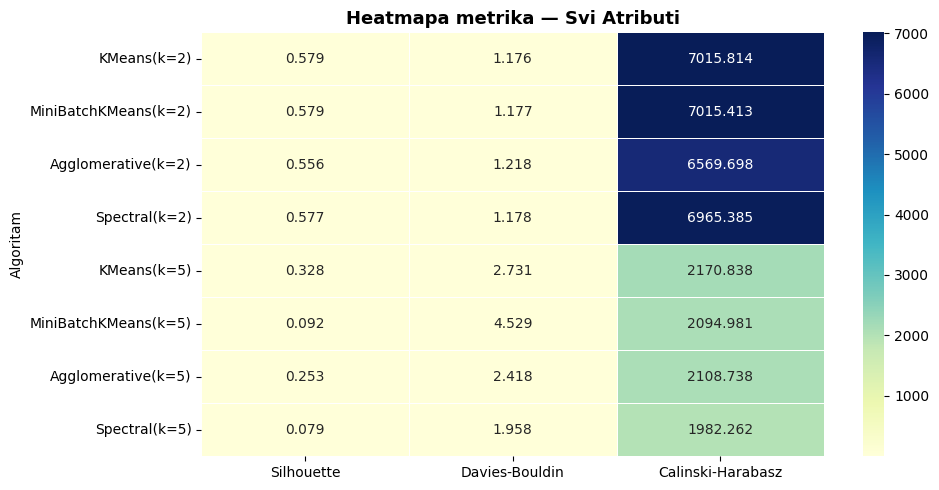

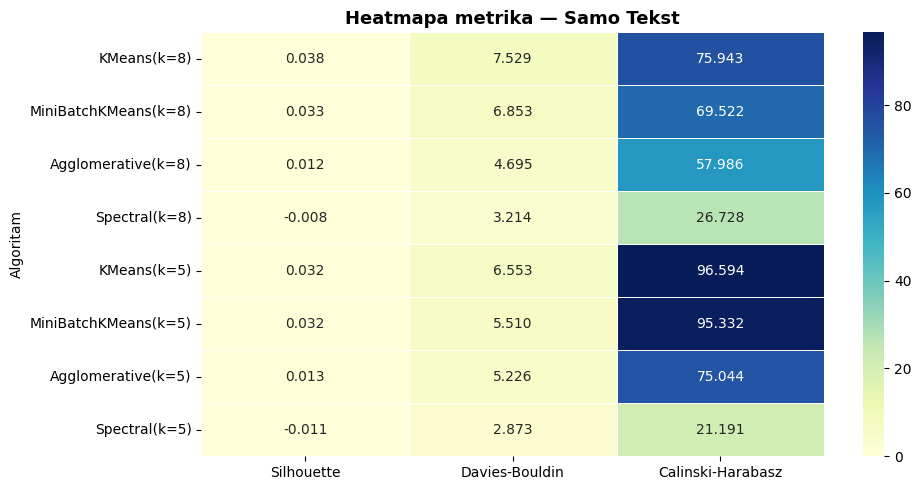

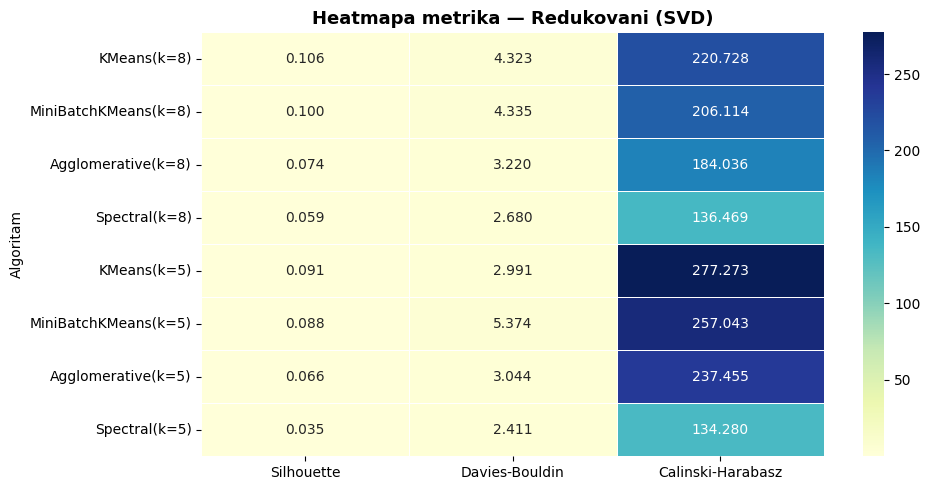

In [13]:
for set_name in ['Svi Atributi', 'Samo Tekst', 'Redukovani (SVD)']:
    subset = df_no_dbscan[df_no_dbscan['Set'] == set_name].set_index('Algoritam')
    subset = subset[['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz']]

    plt.figure(figsize=(10, 5))
    sns.heatmap(subset, annot=True, fmt=".3f", cmap="YlGnBu", linewidths=0.5)
    plt.title(f'Heatmapa metrika — {set_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = set_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(os.path.join(output_dir, f"heatmapa_{fname}.png"), dpi=150)
    plt.show()

<h3>DBSCAN ZASEBNA ANALIZA

In [14]:
print("\n" + "="*70)
print("DBSCAN ANALIZA (zasebno - Silhouette je misleading)")
print("="*70)
print(df_dbscan[['Set', 'Algoritam', 'n_clusters', 'Silhouette']].to_string(index=False))
print("\nNapomena: DBSCAN pronalazi 96-99% suma u svim setovima,")
print("sto ukazuje da TF-IDF prostor nije pogodan za DBSCAN.")


DBSCAN ANALIZA (zasebno - Silhouette je misleading)
             Set                     Algoritam  n_clusters  Silhouette
    Svi Atributi DBSCAN(eps=0.4,min_samples=3)          10    0.588585
      Samo Tekst DBSCAN(eps=0.4,min_samples=3)          14    0.927178
Redukovani (SVD) DBSCAN(eps=0.4,min_samples=3)          30    0.676897

Napomena: DBSCAN pronalazi 96-99% suma u svim setovima,
sto ukazuje da TF-IDF prostor nije pogodan za DBSCAN.


<h3>FINALNI IZVESTAJ - POBEDNICI PO METRIKAMA (bez DBSCAN)

In [15]:
# Silhouette - veci je bolji
best_sil = df_no_dbscan.loc[df_no_dbscan['Silhouette'].idxmax()]

# Davies-Bouldin - manji je bolji
df_db_valid = df_no_dbscan[df_no_dbscan['Davies-Bouldin'].notna() & (df_no_dbscan['Davies-Bouldin'] > 0)]
best_db = df_db_valid.loc[df_db_valid['Davies-Bouldin'].idxmin()]

# Calinski-Harabasz - veci je bolji
best_ch = df_no_dbscan.loc[df_no_dbscan['Calinski-Harabasz'].idxmax()]

print("\n" + "*"*70)
print("FINALNI IZVESTAJ - POBEDNICI PO METRIKAMA (bez DBSCAN)")
print("*"*70)
print(f"\n1. NAJBOLJI SILHOUETTE (Struktura klastera - veci = bolji):")
print(f"   {best_sil['Algoritam']} na setu '{best_sil['Set']}' → {best_sil['Silhouette']:.4f}")

print(f"\n2. NAJBOLJI DAVIES-BOULDIN (Razdvojenost - manji = bolji):")
print(f"   {best_db['Algoritam']} na setu '{best_db['Set']}' → {best_db['Davies-Bouldin']:.4f}")

print(f"\n3. NAJBOLJI CALINSKI-HARABASZ (Gustina i separacija - veci = bolji):")
print(f"   {best_ch['Algoritam']} na setu '{best_ch['Set']}' → {best_ch['Calinski-Harabasz']:.2f}")

print("\n" + "-"*70)
print("ZAKLJUCAK PO SETOVIMA PODATAKA:")
print("-"*70)

for set_name in ['Svi Atributi', 'Samo Tekst', 'Redukovani (SVD)']:
    subset = df_no_dbscan[df_no_dbscan['Set'] == set_name]
    best_algo = subset.loc[subset['Silhouette'].idxmax()]
    avg_sil = subset['Silhouette'].mean()
    print(f"\n  {set_name}:")
    print(f"    Prosecni Silhouette: {avg_sil:.4f}")
    print(f"    Najbolji algoritam: {best_algo['Algoritam']} (Silhouette={best_algo['Silhouette']:.4f})")

print("*"*70)


**********************************************************************
FINALNI IZVESTAJ - POBEDNICI PO METRIKAMA (bez DBSCAN)
**********************************************************************

1. NAJBOLJI SILHOUETTE (Struktura klastera - veci = bolji):
   KMeans(k=2) na setu 'Svi Atributi' → 0.5787

2. NAJBOLJI DAVIES-BOULDIN (Razdvojenost - manji = bolji):
   KMeans(k=2) na setu 'Svi Atributi' → 1.1763

3. NAJBOLJI CALINSKI-HARABASZ (Gustina i separacija - veci = bolji):
   KMeans(k=2) na setu 'Svi Atributi' → 7015.81

----------------------------------------------------------------------
ZAKLJUCAK PO SETOVIMA PODATAKA:
----------------------------------------------------------------------

  Svi Atributi:
    Prosecni Silhouette: 0.3803
    Najbolji algoritam: KMeans(k=2) (Silhouette=0.5787)

  Samo Tekst:
    Prosecni Silhouette: 0.0177
    Najbolji algoritam: KMeans(k=8) (Silhouette=0.0377)

  Redukovani (SVD):
    Prosecni Silhouette: 0.0772
    Najbolji algoritam: KMeans(k=

<h3>BOXPLOT - DISTRIBUCIJA SILHOUETTE PO SETU (bez DBSCAN)

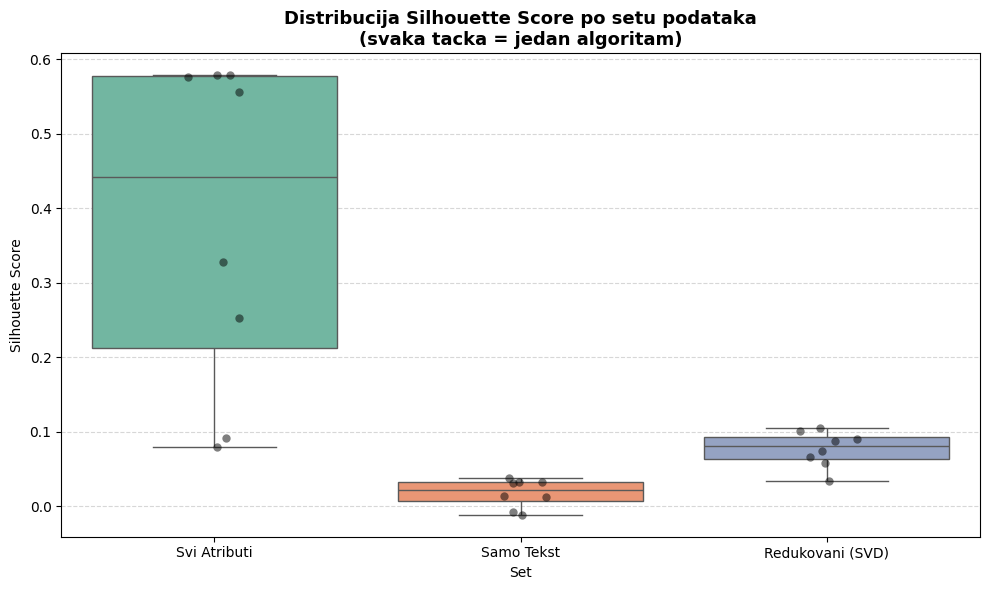


Gotovo! Svi grafici sacuvani u folderu: grafici_final


In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_no_dbscan,
    x='Set', y='Silhouette',
    palette='Set2'
)
sns.stripplot(
    data=df_no_dbscan,
    x='Set', y='Silhouette',
    color='black', alpha=0.5, jitter=True, size=6
)
plt.title('Distribucija Silhouette Score po setu podataka\n(svaka tacka = jedan algoritam)',
          fontsize=13, fontweight='bold')
plt.ylabel('Silhouette Score')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "boxplot_silhouette_po_setu.png"), dpi=150)
plt.show()

print(f"\nGotovo! Svi grafici sacuvani u folderu: {output_dir}")